In [1]:
import numpy as np

# Parameters
L = 50           # Number of grid points per dimension
q = 15           # Charge magnitude
max_iter = 10000 # Maximum iterations
tolerance = 1e-5 # Convergence tolerance

h = 1.0 / (L - 1)  # Grid spacing

# Charge position (nearest to center)
i0 = L // 2 - 1
j0 = L // 2 - 1

# Initialize charge density (delta function approximation)
rho = np.zeros((L, L))
rho[i0, j0] = q / (h**2)

# Source term: 4πh²ρ
source = 4 * np.pi * (h**2) * rho

# Initialize potential and set boundary to 0
V = np.zeros((L, L))

# Optimal relaxation parameter
omega = 2 / (1 + np.pi / L)

# SOR Iteration
for iter in range(max_iter):
    max_error = 0.0
    for i in range(1, L-1):
        for j in range(1, L-1):
            new_val = (1 - omega) * V[i, j] + omega/4 * (
                V[i+1, j] + V[i-1, j] + V[i, j+1] + V[i, j-1] + source[i, j]
            )
            error = abs(new_val - V[i, j])
            if error > max_error:
                max_error = error
            V[i, j] = new_val
    if max_error < tolerance:
        print(f"Converged after {iter + 1} iterations.")
        break
else:
    print("Did not converge within max iterations.")

Converged after 127 iterations.


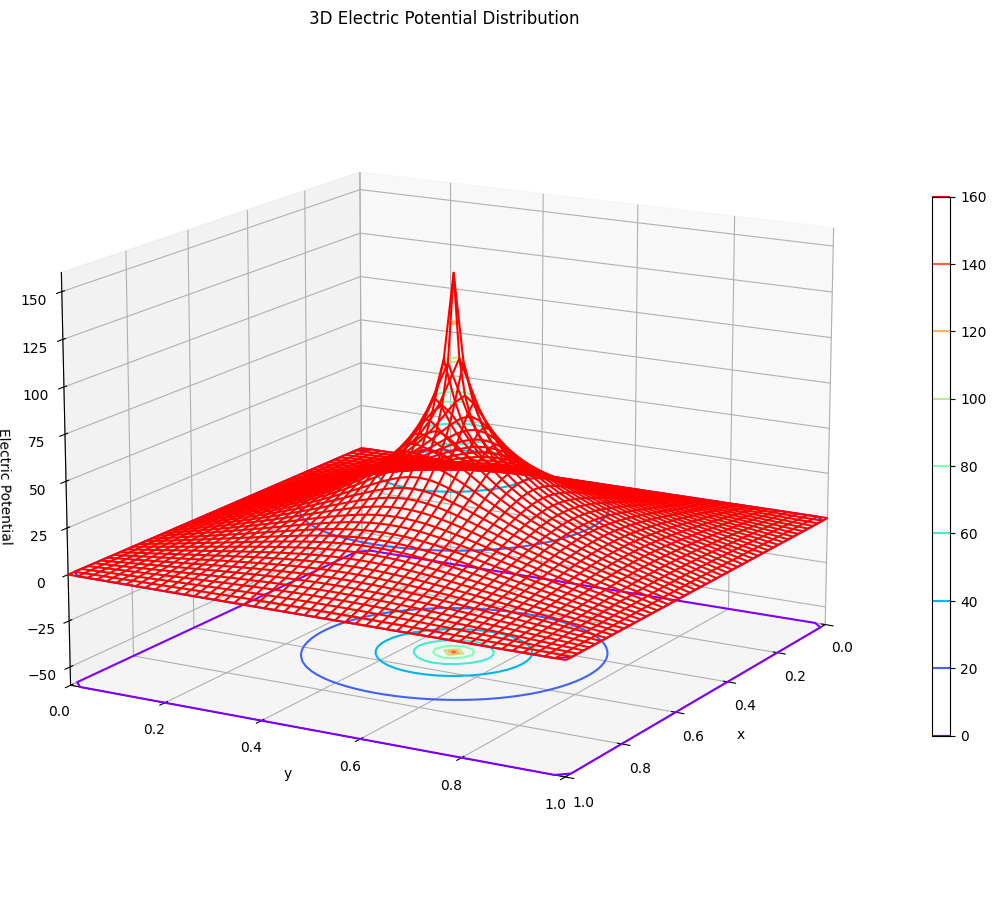

In [2]:
import matplotlib.pyplot as plt

# 生成坐标网格
x = np.linspace(0, 1, L)
y = np.linspace(0, 1, L)
X, Y = np.meshgrid(x, y)

# 创建三维画布
fig = plt.figure(figsize=(14, 14))
ax = fig.add_subplot(111, projection='3d')

# 绘制表面图
surf = ax.plot_wireframe(X, Y, V.T, rstride=1, cstride=1, color = 'r')
contour = ax.contour(X, Y, V, cmap="rainbow")
ax.contour(X, Y, V, zdir='z', offset=-60, cmap="rainbow")
plt.colorbar(contour, shrink=0.5, aspect=30)

# 添加标签和颜色条
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('Electric Potential')
ax.set_title('3D Electric Potential Distribution')

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_zlim(-60, 160)

# 调整视角
ax.view_init(elev=15, azim=30)

plt.show()